In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 300

df = pd.DataFrame({
    "patient_id": range(1, n + 1),
    "age": np.random.randint(18, 85, n),
    "sex": np.random.choice(["male", "female"], n),
    "bmi": np.round(np.random.normal(27, 5, n), 1),
    "systolic_bp": np.random.randint(100, 180, n),
    "glucose": np.round(np.random.normal(5.6, 1.4, n), 1),
    "cholesterol": np.round(np.random.normal(5.2, 1.1, n), 1),
    "smoker": np.random.choice([0, 1], n, p=[0.7, 0.3])
})

df["disease"] = (
    (df["age"] > 55).astype(int)
    + (df["bmi"] > 30).astype(int)
    + (df["systolic_bp"] > 140).astype(int)
    + (df["glucose"] > 6.5).astype(int)
    + df["smoker"]
)

df["disease"] = (df["disease"] >= 3).astype(int)

df.to_csv("../data/raw/patients.csv", index=False)

df.head(20)


,patient_id,age,sex,bmi,systolic_bp,glucose,cholesterol,smoker,disease
0,1,69,female,22.9,133,7.0,5.9,1,1
1,2,32,female,28.2,116,5.3,6.0,1,0
2,3,78,female,28.2,142,5.5,4.9,1,1
3,4,38,female,24.5,158,6.5,6.7,0,0
4,5,41,male,24.6,150,4.0,5.0,0,0
5,6,20,male,28.2,153,6.1,5.3,0,0
6,7,39,female,19.8,123,5.8,5.0,1,0
7,8,70,male,20.0,124,6.3,5.2,1,0
8,9,19,male,23.4,170,6.0,4.0,0,0
9,10,47,female,25.9,151,9.0,3.6,0,0


In [3]:
df.info()
df.describe()
df['disease'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   patient_id   300 non-null    int64  
 1   age          300 non-null    int32  
 2   sex          300 non-null    object 
 3   bmi          300 non-null    float64
 4   systolic_bp  300 non-null    int32  
 5   glucose      300 non-null    float64
 6   cholesterol  300 non-null    float64
 7   smoker       300 non-null    int64  
 8   disease      300 non-null    int64  
dtypes: float64(3), int32(2), int64(3), object(1)
memory usage: 18.9+ KB


disease
0    238
1     62
Name: count, dtype: int64

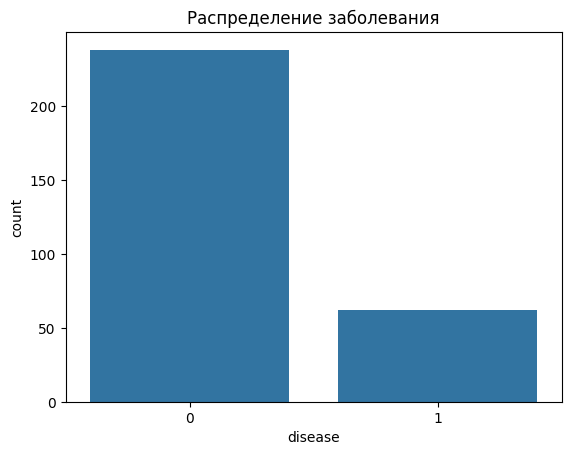

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x = "disease", data = df)
plt.title("Распределение заболевания")
plt.show()

In [5]:
df.groupby("disease")[["age", "bmi", "systolic_bp", "glucose", "cholesterol"]].mean()

,age,bmi,systolic_bp,glucose,cholesterol
disease,,,,,
0,47.142857,26.204202,134.386555,5.687395,5.253361
1,64.419355,29.412903,148.193548,6.409677,5.150000


In [ ]:
sns.boxplot(x = "disease", y = "bmi", data = df)
plt.title("BMI у пациентов с заболеванием и без")
plt.xlabel("Заболевание: 0 - нет, 1 - есть")
plt.ylabel("BMI")
plt.show()

In [ ]:
sns.boxplot(x="disease", y="age", data=df)
plt.title("Возраст у пациентов с заболеванием и без")
plt.xlabel("Заболевание: 0 — нет, 1 — есть")
plt.ylabel("Возраст")
plt.show()